# Task7: Dimensionality Reduction & Stock Price Prediction

## Part 1: Dimensionality Reduction

### 1. Dataset Selection

#### This section explores dimensionality reduction using Principal Component Analysis (PCA) on the Iris dataset. The dataset consists of 150 samples categorized into three species: Setosa, Versicolor, and Virginica. The goal is to reduce the dataset to two principal components while preserving maximum variance.

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn import datasets
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

#### The dataset is loaded, and its feature matrix (X) and target variable (y) are extracted.

In [4]:
iris = datasets.load_iris()
X = iris.data  
y = iris.target  
target_names = iris.target_names
print(target_names)

['setosa' 'versicolor' 'virginica']


### 2. Tasks to Perform

#### The dataset is standardized using StandardScaler() to ensure all features have a mean of zero and a standard deviation of one. PCA is then applied to reduce the dataset dimensions to two principal components.

In [5]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

#### A scatter plot visualizes the transformed dataset, differentiating species using distinct colors.

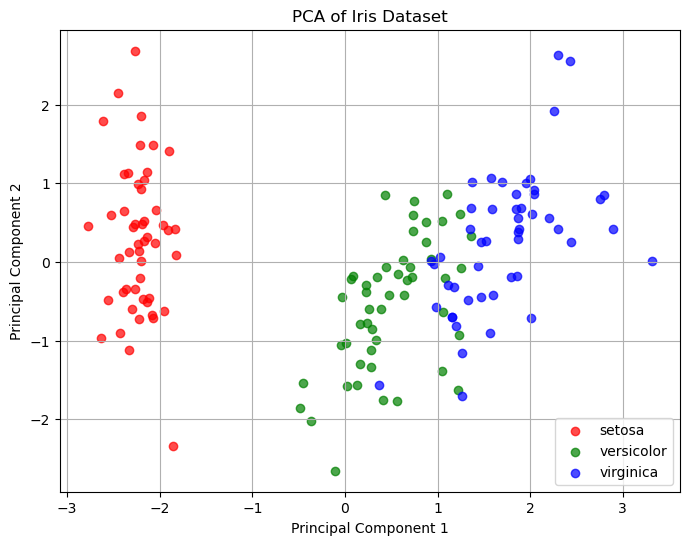

In [6]:
plt.figure(figsize=(8, 6))
colors = ['red', 'green', 'blue']

for i, target_name in enumerate(target_names):
    plt.scatter(X_pca[y == i, 0], X_pca[y == i, 1], alpha=0.7, label=target_name, color=colors[i])

plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('PCA of Iris Dataset')
plt.legend()
plt.grid(True)
plt.show()

## Part 2: Stock Price Prediction Using Time Series Forecasting

### 1. Dataset Selection:
#### This section focuses on forecasting stock prices using an ARIMA model. The dataset is preprocessed to handle missing values, convert date formats, and create relevant features for analysis.

In [7]:
!pip install pmdarima
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.arima.model import ARIMA
from pmdarima import auto_arima
from sklearn.metrics import mean_absolute_error, mean_squared_error

import warnings
warnings.filterwarnings("ignore")

df = pd.read_csv("stock_price.csv")
print(df.head())

  Using cached pmdarima-2.0.4-cp39-cp39-win_amd64.whl (614 kB)
         Date      Symbol Series  Prev Close    Open     High    Low   Last  \
0  2007-11-27  MUNDRAPORT     EQ      440.00  770.00  1050.00  770.0  959.0   
1  2007-11-28  MUNDRAPORT     EQ      962.90  984.00   990.00  874.0  885.0   
2  2007-11-29  MUNDRAPORT     EQ      893.90  909.00   914.75  841.0  887.0   
3  2007-11-30  MUNDRAPORT     EQ      884.20  890.00   958.00  890.0  929.0   
4  2007-12-03  MUNDRAPORT     EQ      921.55  939.75   995.00  922.0  980.0   

    Close    VWAP    Volume      Turnover  Trades  Deliverable Volume  \
0  962.90  984.72  27294366  2.687719e+15     NaN             9859619   
1  893.90  941.38   4581338  4.312765e+14     NaN             1453278   
2  884.20  888.09   5124121  4.550658e+14     NaN             1069678   
3  921.55  929.17   4609762  4.283257e+14     NaN             1260913   
4  969.30  965.65   2977470  2.875200e+14     NaN              816123   

   %Deliverble  
0     

### 2. Tasks to Perform

#### The Date column is converted to DateTime format, missing values are filled using forward fill, and the Date column is set as the index for time-series analysis.

In [8]:
df['Date'] = pd.to_datetime(df['Date'])

df.fillna(method='ffill', inplace=True)
df.set_index('Date', inplace=True)
print("Dataset after preprocessing:\n", df.head())

Dataset after preprocessing:
                 Symbol Series  Prev Close    Open     High    Low   Last  \
Date                                                                       
2007-11-27  MUNDRAPORT     EQ      440.00  770.00  1050.00  770.0  959.0   
2007-11-28  MUNDRAPORT     EQ      962.90  984.00   990.00  874.0  885.0   
2007-11-29  MUNDRAPORT     EQ      893.90  909.00   914.75  841.0  887.0   
2007-11-30  MUNDRAPORT     EQ      884.20  890.00   958.00  890.0  929.0   
2007-12-03  MUNDRAPORT     EQ      921.55  939.75   995.00  922.0  980.0   

             Close    VWAP    Volume      Turnover  Trades  \
Date                                                         
2007-11-27  962.90  984.72  27294366  2.687719e+15     NaN   
2007-11-28  893.90  941.38   4581338  4.312765e+14     NaN   
2007-11-29  884.20  888.09   5124121  4.550658e+14     NaN   
2007-11-30  921.55  929.17   4609762  4.283257e+14     NaN   
2007-12-03  969.30  965.65   2977470  2.875200e+14     NaN   

  

#### The closing prices are plotted over time to visualize trends.

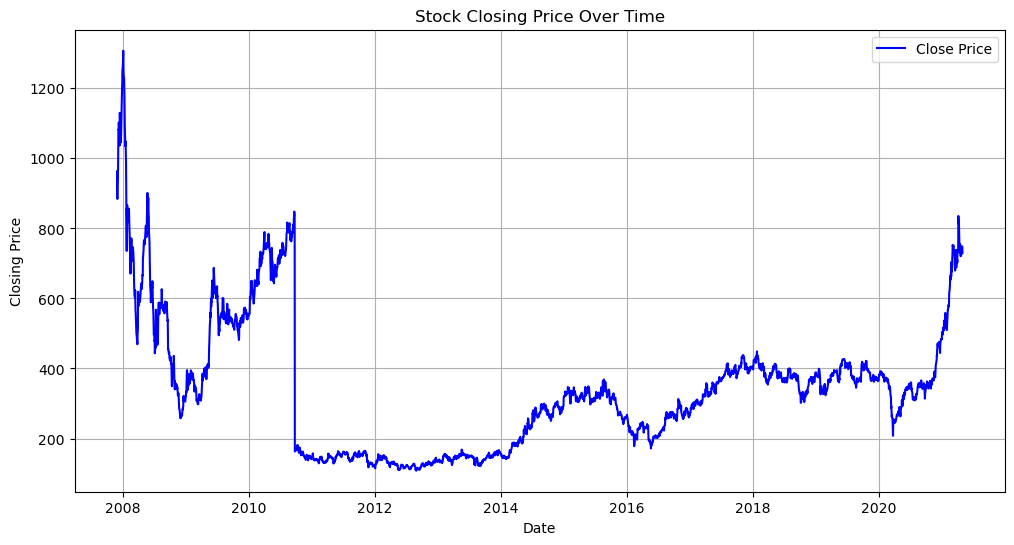

In [9]:
plt.figure(figsize=(12, 6))
plt.plot(df['Close'], color='blue', label="Close Price")
plt.xlabel("Date")
plt.ylabel("Closing Price")
plt.title("Stock Closing Price Over Time")
plt.legend()
plt.grid(True)
plt.show()

#### A seasonal decomposition of the closing price helps identify trend, seasonality, and residual components.

<Figure size 1200x800 with 0 Axes>

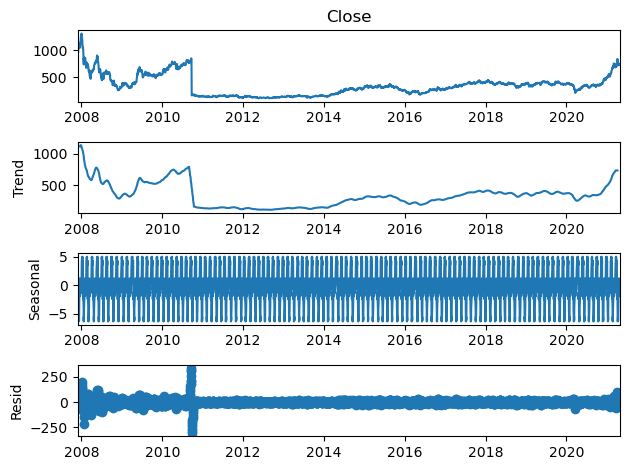

In [10]:
decomposition = seasonal_decompose(df['Close'], model='additive', period=30)
plt.figure(figsize=(12, 8))
decomposition.plot()
plt.show()

### 3. Feature Engineering

#### New features such as lag values and moving averages are created to enhance the forecasting model. Missing values generated from rolling computations are removed.

In [11]:
df['Close_Lag1'] = df['Close'].shift(1)
df['MA_7'] = df['Close'].rolling(window=7).mean()
df['MA_30'] = df['Close'].rolling(window=30).mean()
df.dropna(inplace=True)
print("Dataset after feature engineering:\n", df.head())

Dataset after feature engineering:
                 Symbol Series  Prev Close    Open    High     Low    Last  \
Date                                                                        
2011-06-01  MUNDRAPORT     EQ      161.45  162.10  165.70  161.25  163.50   
2011-06-02  MUNDRAPORT     EQ      164.00  164.00  165.15  160.15  161.15   
2011-06-03  MUNDRAPORT     EQ      161.25  161.50  162.80  159.20  161.00   
2011-06-06  MUNDRAPORT     EQ      161.05  160.50  161.10  159.05  160.00   
2011-06-07  MUNDRAPORT     EQ      159.85  159.85  162.75  156.35  157.00   

             Close    VWAP   Volume      Turnover   Trades  \
Date                                                         
2011-06-01  164.00  164.08  2574106  4.223703e+13  19171.0   
2011-06-02  161.25  162.17  1699298  2.755678e+13  16176.0   
2011-06-03  161.05  161.02  1185817  1.909361e+13  14810.0   
2011-06-06  159.85  160.09   546378  8.746905e+12   7071.0   
2011-06-07  157.25  158.52  2193466  3.477027e+13  1

### 4. Model Training and Prediction

#### The dataset is split into training (80%) and testing (20%) sets. An optimal ARIMA order is determined using auto_arima, and the model is trained on the historical data.

In [12]:
auto_arima_model = auto_arima(df['Close'], seasonal=False, trace=True)
p, d, q = auto_arima_model.order
print(f"Best ARIMA order: p={p}, d={d}, q={q}")

train_size = int(len(df) * 0.8)  
train, test = df['Close'][:train_size], df['Close'][train_size:]

arima_model = ARIMA(train, order=(p, d, q))
arima_result = arima_model.fit()

predictions = arima_result.forecast(steps=len(test))
test_df = test.to_frame()
test_df['Predicted_Close'] = predictions.values

Performing stepwise search to minimize aic
 ARIMA(2,1,2)(0,0,0)[0] intercept   : AIC=16726.204, Time=7.64 sec
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=16742.192, Time=0.11 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=16741.939, Time=0.41 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=16741.850, Time=0.53 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=16742.629, Time=0.09 sec
 ARIMA(1,1,2)(0,0,0)[0] intercept   : AIC=inf, Time=2.14 sec
 ARIMA(2,1,1)(0,0,0)[0] intercept   : AIC=16740.909, Time=2.18 sec
 ARIMA(3,1,2)(0,0,0)[0] intercept   : AIC=16744.642, Time=8.09 sec
 ARIMA(2,1,3)(0,0,0)[0] intercept   : AIC=16744.834, Time=6.29 sec
 ARIMA(1,1,1)(0,0,0)[0] intercept   : AIC=16742.991, Time=1.74 sec
 ARIMA(1,1,3)(0,0,0)[0] intercept   : AIC=16742.707, Time=3.07 sec
 ARIMA(3,1,1)(0,0,0)[0] intercept   : AIC=16742.548, Time=2.88 sec
 ARIMA(3,1,3)(0,0,0)[0] intercept   : AIC=16747.060, Time=8.91 sec
 ARIMA(2,1,2)(0,0,0)[0]             : AIC=16726.732, Time=4.32 sec

Best model:  ARIMA(2,1,2

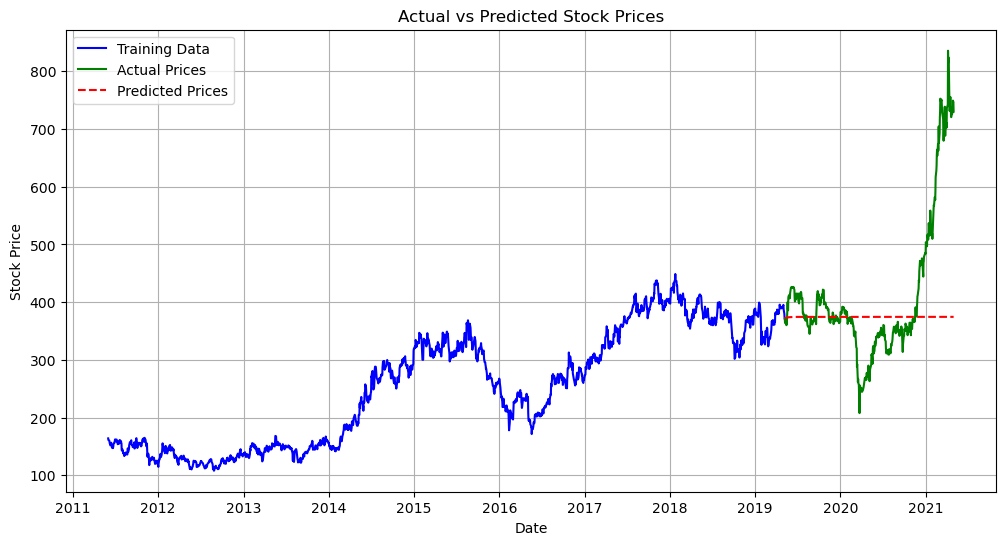

In [13]:
plt.figure(figsize=(12, 6))
plt.plot(train, label="Training Data", color='blue')
plt.plot(test.index, test, label="Actual Prices", color='green')
plt.plot(test.index, test_df['Predicted_Close'], label="Predicted Prices", color='red', linestyle='dashed')
plt.xlabel("Date")
plt.ylabel("Stock Price")
plt.title("Actual vs Predicted Stock Prices")
plt.legend()
plt.grid(True)
plt.show()

### 5. Model Evaluation
#### The model's performance is assessed using MAE, RMSE, and MAPE metrics.

In [14]:
mae = mean_absolute_error(test, test_df['Predicted_Close'])
rmse = np.sqrt(mean_squared_error(test, test_df['Predicted_Close']))
mape = np.mean(np.abs((test - test_df['Predicted_Close']) / test)) * 100

print(f"Model Evaluation Metrics:\nMAE: {mae:.2f}\nRMSE: {rmse:.2f}\nMAPE: {mape:.2f}%")

Model Evaluation Metrics:
MAE: 74.99
RMSE: 126.89
MAPE: 15.66%
